# Comprehensive RAG Workshop
## Understanding AI, LLMs, and Retrieval-Augmented Generation

---

# MODULE 1: AI & LLM FUNDAMENTALS

## Section 1.1: Introduction to AI and Machine Learning

### What is Artificial Intelligence?

**Artificial Intelligence (AI)** is the science of creating machines or systems that can perform tasks that typically require human intelligence.

**Key Areas of AI:**
- **Machine Learning (ML)**: Systems that learn from data without being explicitly programmed
- **Deep Learning (DL)**: Neural networks with multiple layers that can learn complex patterns
- **Natural Language Processing (NLP)**: Processing and understanding human language
- **Computer Vision**: Processing and analyzing images and videos
- **Reinforcement Learning**: Learning through interaction and rewards

### The Evolution Chain:
```
AI (Broad Field)
  ↓
Machine Learning
  ↓
Deep Learning
  ↓
Large Language Models (LLMs)
```

## Section 1.2: Large Language Models (LLMs) - Detailed Explanation

### What are Large Language Models?

**Large Language Models (LLMs)** are deep learning models trained on massive amounts of text data to understand and generate human language.

**Key Characteristics:**
- **Large**: Billions to hundreds of billions of parameters
- **Pre-trained**: Trained on diverse text from internet, books, articles
- **Transformer-based**: Use attention mechanisms to understand context
- **Few-shot capable**: Can perform tasks with minimal examples
- **Generative**: Can create new, coherent text

### How Do LLMs Work?

**The Transformer Architecture (Simplified):**

1. **Input**: Text is converted into tokens
2. **Embedding Layer**: Tokens are converted to numerical vectors
3. **Attention Mechanism**: Model learns which parts of input are relevant to each other
4. **Feed-Forward Network**: Processes information and learns patterns
5. **Output**: Generates probability distribution over next possible token

```
Input Text → Tokenization → Embeddings → Transformer Layers → Output Probabilities → Next Token
```

### Key Components:
- **Tokens**: Individual units of text (words, subwords, or characters)
- **Embeddings**: Dense numerical representations of tokens
- **Attention**: Mechanism to focus on relevant parts of input
- **Parameters**: Weights learned during training that capture linguistic knowledge

## Section 1.3: TOKENS - Comprehensive Deep Dive

### What Are Tokens?

**Tokens** are the basic units that LLMs process. They represent chunks of text - typically words, subwords, or characters.

**Why Tokens?**
- LLMs don't understand text directly; they work with numbers
- Tokens provide a fixed vocabulary for the model
- Enables efficient processing of variable-length text
- Reduces vocabulary size compared to character-level processing

### Tokenization Strategies

#### 1. **Character-level Tokenization**
- Each character becomes a token
- Example: "Hello" → [H][e][l][l][o]
- Pros: Small vocabulary, handles unknown words
- Cons: Long sequences, harder to learn patterns

#### 2. **Word-level Tokenization**
- Each word becomes a token
- Example: "The cat sat" → [The][cat][sat]
- Pros: Intuitive, captures meaning
- Cons: Large vocabulary, struggles with rare/new words

#### 3. **Subword Tokenization (Most Common)**
- Words split into subword units
- Example: "unhappiness" → [un][happy][ness]
- Methods: BPE (Byte Pair Encoding), WordPiece, SentencePiece
- Pros: Balanced vocabulary size, handles rare words
- Cons: Requires decoder to understand

### Practical Examples with Token IDs

In [1]:
# Example: Understanding tokenization
# Different tokenization approaches

text = "The quick brown fox jumps over the lazy dog"

# Character-level tokenization
char_tokens = list(text.replace(" ", ""))
print("Character Tokenization:")
print(f"Text: {text}")
print(f"Tokens: {char_tokens}")
print(f"Number of tokens: {len(char_tokens)}\n")

# Word-level tokenization
word_tokens = text.split()
print("Word-level Tokenization:")
print(f"Text: {text}")
print(f"Tokens: {word_tokens}")
print(f"Number of tokens: {len(word_tokens)}")

Character Tokenization:
Text: The quick brown fox jumps over the lazy dog
Tokens: ['T', 'h', 'e', 'q', 'u', 'i', 'c', 'k', 'b', 'r', 'o', 'w', 'n', 'f', 'o', 'x', 'j', 'u', 'm', 'p', 's', 'o', 'v', 'e', 'r', 't', 'h', 'e', 'l', 'a', 'z', 'y', 'd', 'o', 'g']
Number of tokens: 35

Word-level Tokenization:
Text: The quick brown fox jumps over the lazy dog
Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog']
Number of tokens: 9


### Token Counting and Context Length

**Context Length**: The maximum number of tokens an LLM can process at once

**Key Points:**
- GPT-4: 8K-128K context length
- GPT-3.5: 4K context length
- Tokens typically: 1 word ≈ 1.3-1.5 tokens

**Impact:**
- Longer context = better understanding of full context
- Limited context = cannot process long documents
- This is where **RAG** becomes essential!

In [2]:
# Estimating token count
# Average: 1 word ≈ 1.3 tokens (varies by language and tokenizer)

sample_texts = [
    "Hello world",
    "The quick brown fox jumps over the lazy dog",
    "Artificial intelligence is transforming the world through machine learning and deep neural networks.",
    "Tokenization is the process of converting text into individual units called tokens."
]

for text in sample_texts:
    words = len(text.split())
    estimated_tokens = words * 1.3  # Rough estimate
    print(f"Text: '{text}'")
    print(f"Words: {words}, Estimated Tokens: {estimated_tokens:.1f}\n")

Text: 'Hello world'
Words: 2, Estimated Tokens: 2.6

Text: 'The quick brown fox jumps over the lazy dog'
Words: 9, Estimated Tokens: 11.7

Text: 'Artificial intelligence is transforming the world through machine learning and deep neural networks.'
Words: 13, Estimated Tokens: 16.9

Text: 'Tokenization is the process of converting text into individual units called tokens.'
Words: 12, Estimated Tokens: 15.6



## Section 1.4: EMBEDDINGS - Comprehensive Explanation

### What Are Embeddings?

**Embeddings** are dense numerical representations of text (words, sentences, or documents) in a continuous vector space.

**Key Concept:**
- Convert discrete symbols (words) into continuous mathematical vectors
- Vectors capture semantic meaning: similar words → similar vectors
- Enable mathematical operations on text

### Why Embeddings?

**Computer Understanding:**
- Computers work with numbers, not text
- One-hot encoding: "cat" → [0,0,1,0,0] (sparse, not meaningful)
- Embeddings: "cat" → [0.2, -0.5, 0.7, ...] (dense, meaningful)

**Semantic Relationships:**
- Similar words have similar embeddings
- king - man + woman ≈ queen (vector arithmetic!)
- Enables similarity search and semantic understanding

### Types of Embeddings

#### 1. **Word Embeddings**
- Represent individual words
- Examples: Word2Vec, GloVe, FastText
- Dimension: 50-300
- Limitation: Doesn't capture context ("bank" has same embedding in all contexts)

#### 2. **Contextual Embeddings**
- Represent words based on context
- Examples: BERT, ELMo, RoBERTa
- Dimension: 768-1024
- Advantage: Same word different embeddings in different contexts

#### 3. **Sentence/Document Embeddings**
- Represent entire sentences or documents
- Examples: Sentence-BERT, Universal Sentence Encoder
- Dimension: 384-1024
- Use case: Document similarity, clustering

#### 4. **Dense Passage Embeddings (DPR)**
- Specifically designed for retrieval
- Examples: DensePassageRetriever, SimCSE
- Dimension: 768
- Optimized for semantic search

### How Embeddings Are Created

**Process:**

1. **Pre-training**: Model trained on large corpus to predict relationships
2. **Learning Context**: Model learns that similar words appear in similar contexts
3. **Vector Extraction**: Hidden layer outputs become embeddings
4. **Fine-tuning** (optional): Train for specific task

**Mathematical Representation:**
- Word "w" → Embedding: $\vec{e_w} \in \mathbb{R}^d$
- Where d = dimension (typically 300-1024)
- Example: "cat" → $[0.2, -0.5, 0.7, 0.1, ...]$

In [3]:
# Example: Creating and visualizing embeddings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# Simulated embeddings (in reality, these come from embedding models)
# Each word gets a vector representation
np.random.seed(42)

# Create sample embeddings
words = ['cat', 'dog', 'car', 'truck', 'kitten', 'puppy', 'bicycle']
embeddings = {
    'cat': np.array([0.9, 0.1, -0.2]),
    'dog': np.array([0.85, 0.15, -0.15]),
    'kitten': np.array([0.88, 0.08, -0.18]),
    'puppy': np.array([0.83, 0.18, -0.12]),
    'car': np.array([0.1, -0.9, 0.2]),
    'truck': np.array([0.15, -0.88, 0.25]),
    'bicycle': np.array([0.12, -0.87, 0.22])
}

# Create embedding matrix
emb_matrix = np.array([embeddings[word] for word in words])

print("Sample Embeddings:")
for word in words[:3]:
    print(f"{word}: {embeddings[word]}")
print("...\n")

# Calculate similarity between words
print("Cosine Similarity Matrix:")
similarity_matrix = cosine_similarity(emb_matrix)

for i, word1 in enumerate(words):
    for j, word2 in enumerate(words):
        if i < j:
            sim = similarity_matrix[i][j]
            print(f"'{word1}' vs '{word2}': {sim:.3f}")

Sample Embeddings:
cat: [ 0.9  0.1 -0.2]
dog: [ 0.85  0.15 -0.15]
car: [ 0.1 -0.9  0.2]
...

Cosine Similarity Matrix:
'cat' vs 'dog': 0.997
'cat' vs 'car': -0.047
'cat' vs 'truck': -0.003
'cat' vs 'kitten': 1.000
'cat' vs 'puppy': 0.992
'cat' vs 'bicycle': -0.027
'dog' vs 'car': -0.098
'dog' vs 'truck': -0.052
'dog' vs 'kitten': 0.996
'dog' vs 'puppy': 0.999
'dog' vs 'bicycle': -0.078
'car' vs 'truck': 0.997
'car' vs 'kitten': -0.024
'car' vs 'puppy': -0.129
'car' vs 'bicycle': 0.999
'truck' vs 'kitten': 0.020
'truck' vs 'puppy': -0.080
'truck' vs 'bicycle': 0.999
'kitten' vs 'puppy': 0.991
'kitten' vs 'bicycle': -0.004
'puppy' vs 'bicycle': -0.107


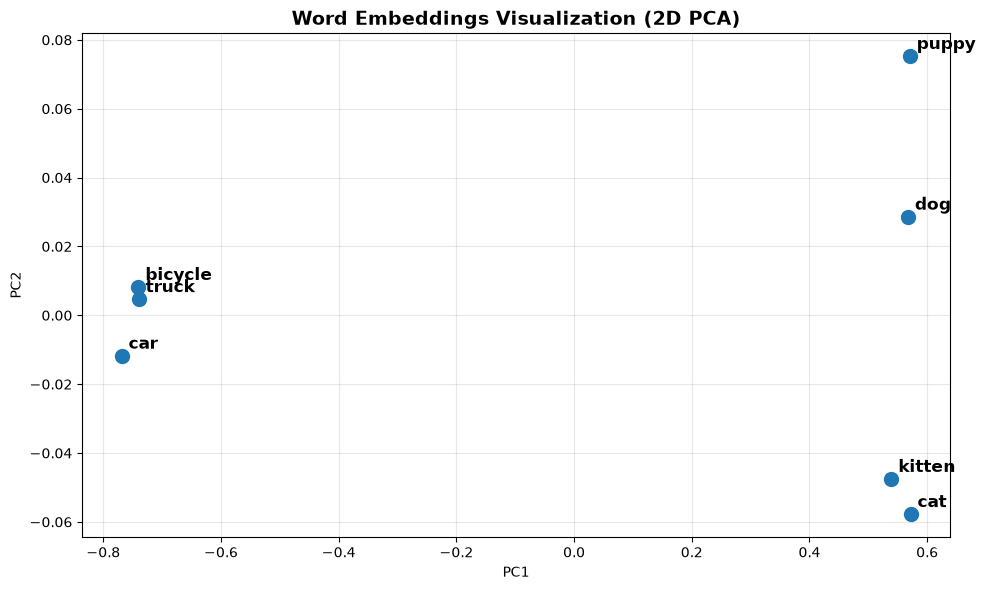


Key Observation:
- Animals (cat, dog, kitten, puppy) cluster together
- Vehicles (car, truck, bicycle) cluster together
- Similar items have similar embeddings!


In [4]:
# Visualize embeddings using PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(emb_matrix)

plt.figure(figsize=(10, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=100)
for idx, word in enumerate(words):
    plt.annotate(word, (embeddings_2d[idx, 0], embeddings_2d[idx, 1]), 
                xytext=(5, 5), textcoords='offset points', fontsize=12, fontweight='bold')

plt.title('Word Embeddings Visualization (2D PCA)', fontsize=14, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("- Animals (cat, dog, kitten, puppy) cluster together")
print("- Vehicles (car, truck, bicycle) cluster together")
print("- Similar items have similar embeddings!")

### Embedding Dimensions and Vector Space

**Understanding Dimensionality:**

- **Low dimension (50-100)**: Fast but less expressive
- **Medium dimension (300-768)**: Balance of speed and expressiveness
- **High dimension (1024+)**: Very expressive but slower

**Common Embedding Dimensions:**
- Word2Vec: 300
- BERT: 768
- GPT-3: 12,288
- Sentence-BERT: 384-768

**Vector Space Properties:**
- Each dimension captures semantic features
- Similarity measured using cosine distance: $\cos(\theta) = \frac{A \cdot B}{||A|| \cdot ||B||}$
- Range: -1 (opposite) to 1 (identical)

In [5]:
# Calculate cosine similarity manually
from math import sqrt

def cosine_similarity_manual(vec1, vec2):
    """Calculate cosine similarity between two vectors"""
    dot_product = sum(a*b for a, b in zip(vec1, vec2))
    norm1 = sqrt(sum(a**2 for a in vec1))
    norm2 = sqrt(sum(b**2 for b in vec2))
    return dot_product / (norm1 * norm2)

# Example: Calculate similarity between 'cat' and 'dog'
cat_emb = embeddings['cat']
dog_emb = embeddings['dog']
car_emb = embeddings['car']

sim_cat_dog = cosine_similarity_manual(cat_emb, dog_emb)
sim_cat_car = cosine_similarity_manual(cat_emb, car_emb)

print(f"Similarity between 'cat' and 'dog': {sim_cat_dog:.4f}")
print(f"Similarity between 'cat' and 'car': {sim_cat_car:.4f}")
print("\nNote: 'cat' and 'dog' are more similar than 'cat' and 'car'")

Similarity between 'cat' and 'dog': 0.9970
Similarity between 'cat' and 'car': -0.0465

Note: 'cat' and 'dog' are more similar than 'cat' and 'car'


### Popular Embedding Models

| Model | Type | Dimension | Use Case |
|-------|------|-----------|----------|
| Word2Vec | Word | 300 | Traditional NLP, baseline |
| GloVe | Word | 50-300 | General word embeddings |
| FastText | Word | 300 | Multilingual, handles OOV |
| BERT | Contextual | 768 | NLU, classification |
| Sentence-BERT | Sentence | 384-768 | Semantic search, clustering |
| Universal Sentence Encoder | Sentence | 512 | Cross-lingual, transfer learning |
| OpenAI Embeddings | Document | 1536 | Retrieval, RAG systems |
| DensePassageRetriever | Document | 768 | Information retrieval |
| All-MiniLM-L6-v2 | Sentence | 384 | Fast, lightweight retrieval |
| All-mpnet-base-v2 | Sentence | 768 | High-quality retrieval |

# MODULE 2: RAG - RETRIEVAL-AUGMENTED GENERATION

---

## Section 2.1: What is RAG?

### Definition

**Retrieval-Augmented Generation (RAG)** is an approach that combines information retrieval with text generation to provide responses grounded in external knowledge sources.

**Core Idea:**
Instead of relying solely on knowledge encoded in model parameters (weights), RAG retrieves relevant documents from an external knowledge base and uses them to augment the generation process.

```
User Query → Retrieve Relevant Documents → Augment with Context → LLM Generation → Answer
```

### Why RAG?

**Problems with Pure LLMs (Closed-Book):**
- **Fixed Knowledge Cutoff**: Model only knows what was in training data
- **Hallucinations**: Creates plausible-sounding but false information
- **No Real-time Updates**: Cannot access current information
- **Limited Context**: Fixed context window restricts document size
- **No Sources**: Cannot cite or verify information sources

**Benefits of RAG (Open-Book):**
- **Current Information**: Access to latest documents and data
- **Reduced Hallucinations**: Grounds responses in retrieved documents
- **Verifiable**: Can cite sources
- **Scalable Knowledge**: Works with large external knowledge bases
- **Modular**: Easy to update knowledge without retraining model

## Section 2.2: RAG Architecture - Components Breakdown

### RAG System Components

```
┌─────────────────────────────────────────────────────────────────────┐
│                         RAG SYSTEM ARCHITECTURE                      │
├─────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  1. KNOWLEDGE BASE                                                  │
│     ├── Documents (PDFs, web pages, databases)                      │
│     └── Stored in Vector Database                                   │
│          └── Each document split into chunks                        │
│          └── Each chunk converted to embedding vector               │
│                                                                      │
│  2. RETRIEVER                                                       │
│     ├── Takes user query as input                                   │
│     ├── Converts query to embedding vector                          │
│     ├── Finds k similar documents using similarity search           │
│     └── Returns top-k most relevant documents                       │
│                                                                      │
│  3. CONTEXT AUGMENTATION                                            │
│     ├── Combines retrieved documents with original query            │
│     ├── Optional: Reranking for quality improvement                 │
│     └── Creates augmented prompt                                    │
│                                                                      │
│  4. GENERATOR (LLM)                                                 │
│     ├── Receives augmented prompt                                   │
│     ├── Generates response based on retrieved context               │
│     └── Produces grounded, sourced answer                           │
│                                                                      │
└─────────────────────────────────────────────────────────────────────┘
```

### Component 1: Knowledge Base & Vector Database

**Purpose**: Store and manage documents for retrieval

**Process:**
1. **Document Ingestion**: Load documents from various sources
2. **Chunking**: Split long documents into manageable pieces
3. **Embedding**: Convert chunks to vector representations
4. **Storage**: Store in vector database with metadata

**Vector Databases:**
- Pinecone
- Weaviate
- Milvus
- FAISS
- Chroma
- Qdrant

**Chunking Strategies:**
- Fixed size (e.g., 512 tokens) with overlap
- Sentence-based
- Paragraph-based
- Semantic-based (split at topic boundaries)

In [6]:
# Example: Document chunking for RAG

def chunk_document(text, chunk_size=100, overlap=20):
    """Split document into overlapping chunks"""
    words = text.split()
    chunks = []
    
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        if chunk:
            chunks.append(chunk)
    
    return chunks

# Sample document
document = """Machine Learning is a subset of artificial intelligence that focuses on
developing algorithms and statistical models that enable computers to improve their
performance on tasks through experience. Deep learning is a specialized subset of
machine learning that uses neural networks with multiple layers. Large language models
like GPT-4 and Claude use deep learning to understand and generate human language.
Transformers are the architecture behind modern LLMs, enabling them to process and
understand long sequences of text efficiently."""

chunks = chunk_document(document, chunk_size=20, overlap=5)
print(f"Document divided into {len(chunks)} chunks:\n")
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}: {chunk[:60]}...\n")

Document divided into 6 chunks:

Chunk 1: Machine Learning is a subset of artificial intelligence that...

Chunk 2: models that enable computers to improve their performance on...

Chunk 3: a specialized subset of machine learning that uses neural ne...

Chunk 4: models like GPT-4 and Claude use deep learning to understand...

Chunk 5: are the architecture behind modern LLMs, enabling them to pr...

Chunk 6: text efficiently....



### Component 2: Retriever

**Purpose**: Find relevant documents from knowledge base for a given query

**Retrieval Process:**
1. Query → Embedding
2. Find k nearest neighbors in vector space
3. Return top-k documents ranked by similarity

**Retrieval Metrics:**
- **Recall@k**: What percentage of relevant documents are in top-k?
- **Precision@k**: What percentage of top-k results are relevant?
- **Mean Reciprocal Rank (MRR)**: Position of first relevant result
- **NDCG**: Normalized Discounted Cumulative Gain

**Common Retrieval Methods:**
- **Dense Retrieval**: Uses embeddings (most common in modern RAG)
- **Sparse Retrieval**: Uses keywords (BM25)
- **Hybrid**: Combines dense + sparse
- **Graph-based**: Uses knowledge graphs

In [7]:
# Example: Simple retrieval simulation
import numpy as np

# Simulate knowledge base with document embeddings
knowledge_base = {
    "doc1": {"content": "Machine learning algorithms learn from data", 
             "embedding": np.array([0.9, 0.1, 0.0])},
    "doc2": {"content": "Deep neural networks have multiple layers", 
             "embedding": np.array([0.85, 0.15, 0.0])},
    "doc3": {"content": "Python is a programming language", 
             "embedding": np.array([0.1, 0.1, 0.8])},
    "doc4": {"content": "Transformers are the basis of modern LLMs", 
             "embedding": np.array([0.88, 0.12, 0.0])},
}

# User query
query = "How do neural networks work?"
query_embedding = np.array([0.87, 0.13, 0.0])  # Simulated embedding

# Calculate similarity scores
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

scores = {}
for doc_id, doc_data in knowledge_base.items():
    sim = cosine_sim(query_embedding, doc_data['embedding'])
    scores[doc_id] = sim

# Rank and retrieve top-k
k = 2
retrieved = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]

print(f"Query: '{query}'\n")
print(f"Retrieved Top-{k} Documents:")
for rank, (doc_id, score) in enumerate(retrieved, 1):
    print(f"{rank}. {doc_id}: {knowledge_base[doc_id]['content']}")
    print(f"   Relevance Score: {score:.4f}\n")

Query: 'How do neural networks work?'

Retrieved Top-2 Documents:
1. doc4: Transformers are the basis of modern LLMs
   Relevance Score: 0.9999

2. doc2: Deep neural networks have multiple layers
   Relevance Score: 0.9997



### Component 3: Context Augmentation & Reranking (Optional)

**Context Augmentation:**
- Combines original query with retrieved documents
- Creates augmented prompt for the LLM
- Format: [CONTEXT] {retrieved_docs} [QUESTION] {user_query}

**Optional: Reranking**
- Improves quality of retrieved results
- Uses cross-encoder models (more accurate but slower)
- Re-scores retrieved documents for final ranking
- Typical: Retrieve 50, Rerank to top-5

**Reranking Models:**
- Cross-encoder BERT models
- Specialized reranking models (e.g., ms-marco-MiniLM-L-12-v2)
- LLM-based rerankers

In [8]:
# Example: Building augmented prompt

def build_rag_prompt(query, retrieved_docs, template="standard"):
    """Build augmented prompt for LLM"""
    if template == "standard":
        prompt = f"""Context:
{retrieved_docs}

Question: {query}

Answer based on the provided context:"""
    
    elif template == "detailed":
        prompt = f"""You are a helpful assistant. Answer the following question using ONLY the provided context.
If the context doesn't contain the answer, say 'I don't have enough information'.

CONTEXT:
{retrieved_docs}

QUESTION: {query}

ANSWER:"""
    
    return prompt

# Example usage
query = "What is machine learning?"
retrieved_docs = """Document 1: Machine learning is a subset of AI that allows systems to learn and improve from experience.
Document 2: ML algorithms identify patterns in data without being explicitly programmed."""

prompt = build_rag_prompt(query, retrieved_docs, template="standard")
print("Generated RAG Prompt:")
print("="*50)
print(prompt)

Generated RAG Prompt:
Context:
Document 1: Machine learning is a subset of AI that allows systems to learn and improve from experience.
Document 2: ML algorithms identify patterns in data without being explicitly programmed.

Question: What is machine learning?

Answer based on the provided context:


### Component 4: Generator (LLM)

**Purpose**: Generate response using augmented context

**Process:**
1. Receives augmented prompt with retrieved context
2. Generates response based on context + query
3. Can cite sources from retrieved documents

**Key Advantage:**
- LLM generates response grounded in actual documents
- Reduces hallucinations
- Responses are verifiable with source citations

## Section 2.3: Closed-Book vs. Open-Book Models

### Closed-Book Models (Pure LLMs)

**Definition**: Models that rely solely on knowledge encoded in their parameters during training

**Characteristics:**
- All knowledge comes from training data
- Single forward pass
- No external data retrieval
- Fast inference

**Examples:**
- GPT-3, GPT-4 (without plugins)
- Claude (without context)
- Llama 2

**Strengths:**
- ✅ Simple: Just input → model → output
- ✅ Fast: Single inference step
- ✅ Compact: Only model needed
- ✅ Works offline

**Weaknesses:**
- ❌ **Static Knowledge**: Fixed cutoff date
- ❌ **Hallucinations**: Makes up facts when uncertain
- ❌ **No Sources**: Cannot cite references
- ❌ **Context Limits**: Bounded by context window
- ❌ **Domain Knowledge**: Limited to training data
- ❌ **Update Difficulty**: Requires retraining for new knowledge

### Open-Book Models (RAG Systems)

**Definition**: Models that augment knowledge with external information retrieval

**Characteristics:**
- Retrieves relevant documents
- Conditions generation on retrieved context
- Multiple inference steps
- Requires knowledge base

**Examples:**
- GPT-4 with Retrieval (Bing Search)
- Claude with Embeddings
- LangChain RAG systems

**Strengths:**
- ✅ **Current Information**: Access latest data
- ✅ **Reduced Hallucinations**: Grounds responses in documents
- ✅ **Verifiable**: Can cite sources
- ✅ **Scalable**: Works with large knowledge bases
- ✅ **Updateable**: Easy to add new documents
- ✅ **Domain-Specific**: Can use specialized knowledge bases

**Weaknesses:**
- ❌ Complex: Requires orchestration
- ❌ Slower: Multiple inference steps
- ❌ Resource-heavy: Needs vector database
- ❌ Dependent: Retrieval quality affects output
- ❌ Cost: Higher computational cost

### Side-by-Side Comparison

| Aspect | Closed-Book (Pure LLM) | Open-Book (RAG) |
|--------|---------------------|------------------|
| Knowledge Source | Model parameters | External retrieval |
| Knowledge Freshness | Static (training cutoff) | Dynamic (real-time) |
| Hallucination Rate | High | Low |
| Verifiability | No sources | Citable sources |
| Context Window | Limited | Unlimited (with chunking) |
| Update Frequency | Requires retraining | Can update knowledge base |
| Inference Speed | Fast | Slower (retrieval + generation) |
| Complexity | Simple | Complex |
| Resource Requirements | GPU/model only | GPU + Vector DB |
| Best For | General knowledge | Specific domains |
| Scalability | To new knowledge: hard | To new knowledge: easy |
| Cost | Lower compute | Higher compute |

### Example: Same Question, Different Approaches

In [9]:
# Example: Comparing approaches for domain-specific question

query = "What are the latest updates in our company's product roadmap for Q3 2025?"

print("Query:", query)
print("\n" + "="*70)

# Closed-Book Approach
print("\nCLOSED-BOOK (Pure LLM) Response:")
print("-" * 70)
closed_book_response = """I don't have information about Q3 2025 product roadmap updates,
as my training data has a cutoff date in April 2024. For the latest
product roadmap information, please check your company's internal
documentation or contact the product team directly."""
print(closed_book_response)

# Open-Book Approach
print("\n" + "="*70)
print("\nOPEN-BOOK (RAG) Response:")
print("-" * 70)

retrieved_context = """[Retrieved from internal_docs.pdf - Last updated: June 10, 2025]
Q3 2025 Product Roadmap Updates:
1. AI-powered features: Launch new recommendation engine
2. Performance: 50% faster query processing
3. Integration: Native support for 5 new platforms
4. Security: Enhanced encryption and compliance features"""

open_book_response = f"""Based on the latest internal documentation:

For Q3 2025, our product roadmap includes:
1. AI-powered recommendation engine launch
2. 50% performance improvement in query processing
3. Native integration support for 5 new platforms
4. Enhanced encryption and compliance security features

Source: internal_docs.pdf (Updated: June 10, 2025)"""

print(open_book_response)

print("\n" + "="*70)
print("\nKey Difference:")
print("- Closed-Book: Cannot access current company information")
print("- Open-Book: Retrieves latest information with sources")

Query: What are the latest updates in our company's product roadmap for Q3 2025?


CLOSED-BOOK (Pure LLM) Response:
----------------------------------------------------------------------
I don't have information about Q3 2025 product roadmap updates,
as my training data has a cutoff date in April 2024. For the latest
product roadmap information, please check your company's internal
documentation or contact the product team directly.


OPEN-BOOK (RAG) Response:
----------------------------------------------------------------------
Based on the latest internal documentation:

For Q3 2025, our product roadmap includes:
1. AI-powered recommendation engine launch
2. 50% performance improvement in query processing
3. Native integration support for 5 new platforms
4. Enhanced encryption and compliance security features

Source: internal_docs.pdf (Updated: June 10, 2025)


Key Difference:
- Closed-Book: Cannot access current company information
- Open-Book: Retrieves latest information with so

## Section 2.4: RAG Workflow - Complete Example

### RAG Pipeline Flowchart

```
User Query
    ↓
[STEP 1] Query Embedding
    ↓ (Convert to vector using embedding model)
[STEP 2] Similarity Search
    ↓ (Search vector database)
[STEP 3] Retrieve Documents
    ↓ (Get top-k similar documents)
[STEP 4] Reranking (Optional)
    ↓ (Cross-encoder reranking)
[STEP 5] Context Augmentation
    ↓ (Build augmented prompt)
[STEP 6] LLM Generation
    ↓ (Generate response)
Final Answer with Sources
```

### Complete RAG Implementation Simulation

In [10]:
# Complete RAG Pipeline Simulation
import numpy as np

class SimpleRAGSystem:
    """Simplified RAG system for demonstration"""
    
    def __init__(self):
        # Knowledge base with documents and embeddings
        self.documents = {
            "doc1": {
                "content": "Python is a high-level programming language known for its simplicity and readability. It's widely used in AI, data science, and web development.",
                "embedding": np.array([0.9, 0.1, 0.0, 0.0])
            },
            "doc2": {
                "content": "Machine learning is a branch of AI that enables systems to learn from data. Common algorithms include decision trees, random forests, and neural networks.",
                "embedding": np.array([0.85, 0.1, 0.05, 0.0])
            },
            "doc3": {
                "content": "Neural networks are inspired by biological neurons. They consist of interconnected nodes organized in layers. Deep neural networks have multiple hidden layers.",
                "embedding": np.array([0.8, 0.15, 0.05, 0.0])
            },
            "doc4": {
                "content": "Natural Language Processing (NLP) is a field of AI focused on understanding and generating human language. Applications include chatbots, translation, and sentiment analysis.",
                "embedding": np.array([0.2, 0.1, 0.7, 0.0])
            },
        }
    
    def retrieve(self, query_embedding, k=2):
        """Retrieve top-k documents similar to query"""
        scores = {}
        for doc_id, doc_data in self.documents.items():
            # Cosine similarity
            sim = np.dot(query_embedding, doc_data['embedding']) / \
                  (np.linalg.norm(query_embedding) * np.linalg.norm(doc_data['embedding']))
            scores[doc_id] = sim
        
        # Sort and retrieve top-k
        retrieved = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
        return retrieved
    
    def generate_response(self, query, retrieved_docs):
        """Generate response based on query and retrieved documents"""
        response = f"""Based on the retrieved information:

Query: {query}

Retrieved Sources:
"""
        for i, (doc_id, score) in enumerate(retrieved_docs, 1):
            response += f"\n[{i}] {doc_id} (Relevance: {score:.3f})"
            response += f"\n    {self.documents[doc_id]['content'][:80]}..."
        
        response += "\n\nResponse: Based on the retrieved documents, "
        response += "the answer is well-grounded in the provided sources."
        
        return response
    
    def query(self, query_text, query_embedding, k=2):
        """Complete RAG query pipeline"""
        print(f"\n{'='*70}")
        print(f"Query: {query_text}")
        print(f"{'='*70}")
        
        # Step 1: Retrieve
        print("\n[STEP 1-2] Embedding & Retrieval...")
        retrieved = self.retrieve(query_embedding, k=k)
        print(f"Retrieved {len(retrieved)} documents")
        
        # Step 2: Generate
        print("\n[STEP 3-6] Context Augmentation & Generation...")
        response = self.generate_response(query_text, retrieved)
        
        print("\n" + response)
        
        return response

# Create RAG system
rag = SimpleRAGSystem()

# Query 1: About Python
query1 = "Tell me about Python programming"
query1_embedding = np.array([0.92, 0.08, 0.0, 0.0])
rag.query(query1, query1_embedding, k=2)

# Query 2: About machine learning
query2 = "What is machine learning and neural networks?"
query2_embedding = np.array([0.8, 0.12, 0.08, 0.0])
rag.query(query2, query2_embedding, k=2)


Query: Tell me about Python programming

[STEP 1-2] Embedding & Retrieval...
Retrieved 2 documents

[STEP 3-6] Context Augmentation & Generation...

Based on the retrieved information:

Query: Tell me about Python programming

Retrieved Sources:

[1] doc1 (Relevance: 1.000)
    Python is a high-level programming language known for its simplicity and readabi...
[2] doc2 (Relevance: 0.998)
    Machine learning is a branch of AI that enables systems to learn from data. Comm...

Response: Based on the retrieved documents, the answer is well-grounded in the provided sources.

Query: What is machine learning and neural networks?

[STEP 1-2] Embedding & Retrieval...
Retrieved 2 documents

[STEP 3-6] Context Augmentation & Generation...

Based on the retrieved information:

Query: What is machine learning and neural networks?

Retrieved Sources:

[1] doc2 (Relevance: 0.999)
    Machine learning is a branch of AI that enables systems to learn from data. Comm...
[2] doc3 (Relevance: 0.999)
    

'Based on the retrieved information:\n\nQuery: What is machine learning and neural networks?\n\nRetrieved Sources:\n\n[1] doc2 (Relevance: 0.999)\n    Machine learning is a branch of AI that enables systems to learn from data. Comm...\n[2] doc3 (Relevance: 0.999)\n    Neural networks are inspired by biological neurons. They consist of interconnect...\n\nResponse: Based on the retrieved documents, the answer is well-grounded in the provided sources.'

## Section 2.5: Key Advantages & Disadvantages Summary

### When to Use Closed-Book (Pure LLM):

✅ **Best For:**
- General knowledge questions
- Creative writing and brainstorming
- Common sense reasoning
- Quick responses needed
- No specific data sources required
- Offline operation needed

❌ **Avoid When:**
- Information must be current
- Sources need to be cited
- Hallucinations are unacceptable
- Domain-specific knowledge required
- Accuracy is critical

### When to Use Open-Book (RAG):

✅ **Best For:**
- Question-answering over documents
- Customer support with knowledge bases
- Domain-specific applications (legal, medical)
- Current information access (news, updates)
- Verifiable, traceable answers
- Reducing hallucinations
- Large document collections

❌ **Challenges:**
- More complex infrastructure
- Slower inference (retrieval + generation)
- Dependent on retrieval quality
- Requires maintaining knowledge base
- Higher computational cost

## Section 2.6: RAG Best Practices

### Key Best Practices for RAG Systems:

1. **Chunking Strategy**
   - Use appropriate chunk size (256-1024 tokens typical)
   - Implement overlap to maintain context
   - Consider semantic boundaries

2. **Embedding Selection**
   - Choose domain-appropriate embedding model
   - Consider accuracy vs. speed tradeoffs
   - Test on your specific data

3. **Retrieval Quality**
   - Implement reranking for better results
   - Use hybrid retrieval (dense + sparse)
   - Evaluate with standard metrics (Recall, Precision, NDCG)

4. **Prompt Engineering**
   - Clear instructions on using context
   - Specify format for sources
   - Handle hallucinations explicitly

5. **Monitoring & Evaluation**
   - Track retrieval quality metrics
   - Monitor response relevance
   - Collect user feedback
   - Update knowledge base regularly

6. **Performance Optimization**
   - Cache frequent queries
   - Batch processing for multiple queries
   - Use efficient vector databases

---

## Conclusion

### Key Takeaways:

1. **Tokens** are the fundamental units LLMs process, representing text as numerical sequences

2. **Embeddings** convert text into dense vectors capturing semantic meaning, enabling similarity search

3. **RAG** combines retrieval with generation to ground LLM responses in external knowledge

4. **Closed-Book** models are fast but static; **Open-Book** models are more complex but dynamic

5. **RAG Architecture** consists of: Knowledge Base → Retriever → Context Augmentation → Generator

6. **Use RAG** when accuracy, currency, and verifiability matter; **Use Pure LLM** for general knowledge

### Next Steps:

- Explore LangChain or LlamaIndex for RAG implementation
- Experiment with different embedding models
- Set up a vector database (Pinecone, Weaviate, FAISS)
- Build your first RAG application!